In [48]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import configparser
import copy
import csv
import pathlib

import colors, file_helpers

colors_lst, _, _ = colors.color_scheme()

In [57]:
path_exp_1 = 'data/measurements/Feb26/1101/buckle=1101.csv'
path_exp_2 = 'data/measurements/Feb26/flipped/1101/buckle=1101.csv'
path_exp_3 = 'data/measurements/Feb25/x=160_buckle=1101.csv'
path_exp_4 = 'data/measurements/Feb17/x=160_buckle=0010_deg=15/x=160_buckle=0010.csv'
path_exp_5 = 'data/measurements/Mar9/buckle=1101.csv'

err=0.01*1e3

x_y_theta_vec_exp = []
F_vec_exp = []
for i, path in enumerate([path_exp_1, path_exp_2, path_exp_3, path_exp_4, path_exp_5]):
    rows = file_helpers.load_pos_force(path)  # uses your CSV format
    x_y_theta_vec_exp.append(np.array([r["pos"] for r in rows], dtype=float))
    F_vec_exp.append(np.array([r["force"] for r in rows], dtype=float))
    if path == 'data/measurements/Feb17/x=160_buckle=0001/x=160_buckle=0001.csv':
        F_vec_exp[i] = 1e3 * F_vec_exp[i]

y_pos = y_pos = x_y_theta_vec_exp[0][:, 1]


# path_sim_1 = 'C:/Users/owner/OneDrive - huji.ac.il/PhD/Research/Bistable shape acquisition jax/Predetermined trajectory/Feb23/0010/L=0.045_buckle[-1 -1  1 -1].csv'
# path_sim_2 = 'C:/Users/owner/OneDrive - huji.ac.il/PhD/Research/Bistable shape acquisition jax/Predetermined trajectory/Feb27/0010/L=0.045_buckle[-1 -1  1 -1].csv'
# path_sim_3 = 'C:/Users/owner/OneDrive - huji.ac.il/PhD/Research/Bistable shape acquisition jax/Predetermined trajectory/Feb26/Leon/0010/L=0.045_buckle[-1 -1  1 -1].csv'
# path_sim_4 = 'C:/Users/owner/OneDrive - huji.ac.il/PhD/Research/Bistable shape acquisition jax/Predetermined trajectory/Feb24/0010/L=0.045_buckle[-1 -1  1 -1].csv'

# F_vec_sim = []
# for i, path in enumerate([path_sim_1, path_sim_2, path_sim_3, path_sim_4]):
#     rows = file_helpers.load_pos_force(path)  # uses your CSV format
#     F_vec_sim.append(np.array([r["force"] for r in rows], dtype=float))

ValueError: File must contain either 'tip_angle_deg' or 'tip_angle_rad'

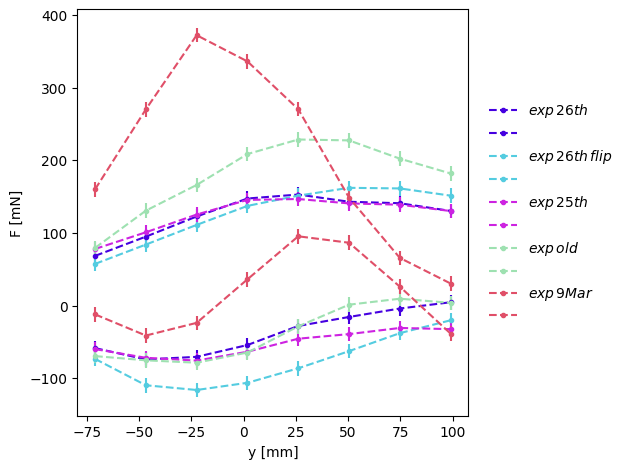

In [54]:
handles = []
labels = []

y_pos = x_y_theta_vec_exp[0][:, 1]
exp_labels = [r'$exp\,26th$', r'$exp\,26th\,flip$', r'$exp\,25th$', r'$exp\,old$' , r'$exp\,9Mar$']

for i, label in enumerate(exp_labels):
    h1 = plt.errorbar(y_pos, F_vec_exp[i][:, 0], yerr=err,
                     color=colors_lst[i], fmt='.', linestyle='--')
    h2 = plt.errorbar(y_pos, F_vec_exp[i][:, 1], yerr=err,
                     color=colors_lst[i], fmt='.', linestyle='--')

    # h1/h2 are ErrorbarContainer; legend wants the main line:
    handles += [h1.lines[0], h2.lines[0]]
    labels  += [label, ""]   # keep your blank entry trick

# sim_labels = [r'$26th\,mean$', r'$23rd$', r'$23rd\,other\,end$', r'$Leon$']
# for i in range(4):
#     l1, = plt.plot(y_pos, F_vec_sim[i][:, 0], color=colors_lst[i], linestyle='-')
#     l2, = plt.plot(y_pos, F_vec_sim[i][:, 1], color=colors_lst[i], linestyle='-')
#     handles += [l1, l2]
#     labels  += [sim_labels[i], ""]

ax = plt.gca()
ax.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.ylabel('F [mN]')
# plt.ylim([-100, 280])
plt.xlabel('y [mm]')
plt.tight_layout()
plt.savefig("0001_wOldChain.png", dpi=300, bbox_inches="tight")
plt.show()

In [45]:
path_exp_1 = 'data/measurements/Feb26/1101/buckle=1101.csv'

err=0.01*1e3

x_y_theta_vec_exp = []
F_vec_exp = []
for i, path in enumerate([path_exp_1]):
    rows = file_helpers.load_pos_force(path)  # uses your CSV format
    x_y_theta_vec_exp.append(np.array([r["pos"] for r in rows], dtype=float))
    F_vec_exp.append(np.array([r["force"] for r in rows], dtype=float))
    if path == 'data/measurements/Feb17/x=160_buckle=0001/x=160_buckle=0001.csv':
        F_vec_exp[i] = 1e3 * F_vec_exp[i]

y_pos = y_pos = x_y_theta_vec_exp[0][:, 1]


path_sim_1 = 'C:/Users/owner/OneDrive - huji.ac.il/PhD/Research/Bistable shape acquisition jax/Predetermined trajectory/Feb26/Leon/1101/L=0.045_buckle[ 1  1 -1  1].csv'
path_sim_2 = 'C:/Users/owner/OneDrive - huji.ac.il/PhD/Research/Bistable shape acquisition jax/Predetermined trajectory/Feb26/greater_angle/L=0.045_buckle[ 1  1 -1  1].csv'
path_sim_3 = 'C:/Users/owner/OneDrive - huji.ac.il/PhD/Research/Bistable shape acquisition jax/Predetermined trajectory/Feb26/tip_totheRight/L=0.045_buckle[ 1  1 -1  1].csv'
path_sim_4 = 'C:/Users/owner/OneDrive - huji.ac.il/PhD/Research/Bistable shape acquisition jax/Predetermined trajectory/Feb26/tip_up/L=0.045_buckle[ 1  1 -1  1].csv'

F_vec_sim = []
for i, path in enumerate([path_sim_1, path_sim_2, path_sim_3, path_sim_4]):
    rows = file_helpers.load_pos_force(path)  # uses your CSV format
    F_vec_sim.append(np.array([r["force"] for r in rows], dtype=float))

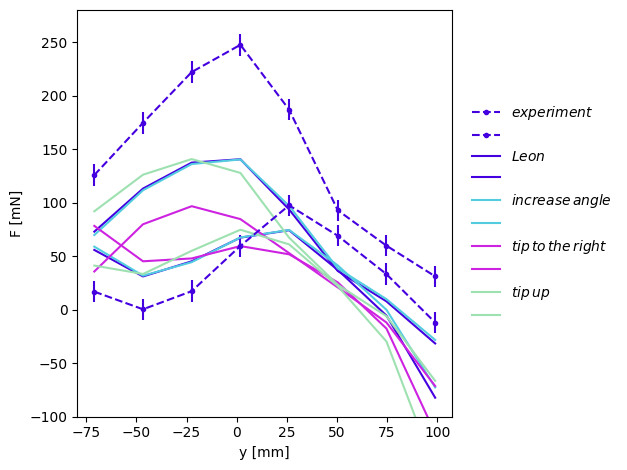

In [46]:
handles = []
labels = []

y_pos = x_y_theta_vec_exp[0][:, 1]
exp_labels = [r'$experiment$' ]

for i, label in enumerate(exp_labels):
    h1 = plt.errorbar(y_pos, F_vec_exp[i][:, 0], yerr=err,
                     color=colors_lst[i], fmt='.', linestyle='--')
    h2 = plt.errorbar(y_pos, F_vec_exp[i][:, 1], yerr=err,
                     color=colors_lst[i], fmt='.', linestyle='--')

    # h1/h2 are ErrorbarContainer; legend wants the main line:
    handles += [h1.lines[0], h2.lines[0]]
    labels  += [label, ""]   # keep your blank entry trick

sim_labels = [r'$Leon$', r'$increase\,angle$', r'$tip\,to\,the\,right$', r'$tip\,up$']
for i in range(4):
    l1, = plt.plot(y_pos, F_vec_sim[i][:, 0], color=colors_lst[i], linestyle='-')
    l2, = plt.plot(y_pos, F_vec_sim[i][:, 1], color=colors_lst[i], linestyle='-')
    handles += [l1, l2]
    labels  += [sim_labels[i], ""]

ax = plt.gca()
ax.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.ylabel('F [mN]')
plt.ylim([-100, 280])
plt.xlabel('y [mm]')
plt.tight_layout()
plt.savefig("different_sims_1101.png", dpi=300, bbox_inches="tight")
plt.show()